# Day 4: Multi Objective Optimisation
Real mining decisions usually involve more than one goal. Increasing production can increase fuel use,
emissions, congestion, and cost. Multi-objective optimization does not return one answer. It returns a set
of trade-off solutions, often called the Pareto front.

In this example, we optimise the number of trucks, based on emissions and production.

{'trucks': np.int64(1), 'production': np.int64(955), 'emissions': np.int64(128)}
{'trucks': np.int64(2), 'production': np.int64(1820), 'emissions': np.int64(272)}
{'trucks': np.int64(3), 'production': np.int64(2595), 'emissions': np.int64(432)}
{'trucks': np.int64(4), 'production': np.int64(3280), 'emissions': np.int64(608)}
{'trucks': np.int64(5), 'production': np.int64(3875), 'emissions': np.int64(800)}
{'trucks': np.int64(6), 'production': np.int64(4380), 'emissions': np.int64(1008)}
{'trucks': np.int64(7), 'production': np.int64(4795), 'emissions': np.int64(1232)}
{'trucks': np.int64(8), 'production': np.int64(5120), 'emissions': np.int64(1472)}
{'trucks': np.int64(9), 'production': np.int64(5355), 'emissions': np.int64(1728)}
{'trucks': np.int64(10), 'production': np.int64(5500), 'emissions': np.int64(2000)}
{'trucks': np.int64(11), 'production': np.int64(5555), 'emissions': np.int64(2288)}
{'trucks': np.int64(12), 'production': np.int64(5520), 'emissions': np.int64(2592)}


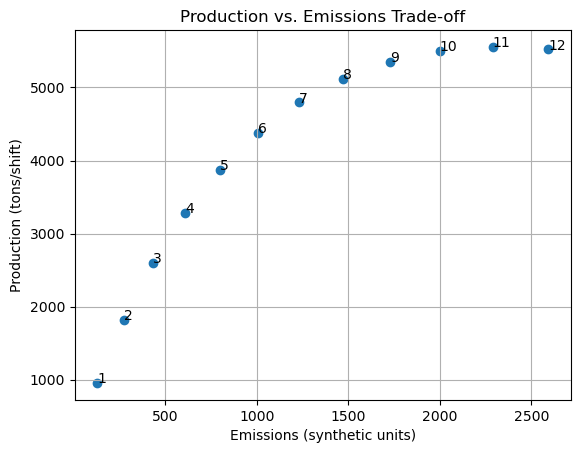

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# I changed the number fo trucks to 12, so we include the dominated solutions for learing
truck_options = np.arange(1, 13)

# Synthetic relationships for learning only
production = 1000 * truck_options - 45 * truck_options**2
emissions = 120 * truck_options + 8 * truck_options**2

# Convert production to a minimization objective by using negative production
solutions = []
for trucks, prod, emis in zip(truck_options, production, emissions):
    solutions.append({"trucks": trucks, "production": prod, "emissions": emis})

for s in solutions:
    print(s)

plt.figure()
plt.scatter(emissions, production)

for trucks, emis, prod in zip(truck_options, emissions, production):
    plt.text(emis, prod, str(trucks))

plt.xlabel("Emissions (synthetic units)")
plt.ylabel("Production (tons/shift)")
plt.title("Production vs. Emissions Trade-off")
plt.grid(True)
plt.show()

## Results
---
We took the number of trucks to be 12. The trade-offs for 12 trucks has been observed.
Both Production and Emissions increase till n=11. These 11 solutions are therefore potential solutions, aka pareto front.  
Any number of trucks from these can be chosen as per requirement.

**n = 11** is the pareto optimal solution.

At n >= 12, all the solutions are dominated. The Emmisions increase but the productions decreases.
This can be attributed to the fact that we observed in DES. After a certain number of trucks, the production
drops because of congestion. However, Emissions keep increasing because the engines donot shut down. 

If the mine manager cares about both emissions and production, they can have 11 trucks(pareto optimal) for maximum production at equivalent emissions. They can choose any number of trucks from 1 to 11, based on the production requirement.

**Pareto Optimal**: A solution is called pareto optimal, if one parameter cannot be improved further without detoriating the others.

**Pareto Front**: set of best trade-off solutions where improving one objective worsens another.

**Dominated Solution**: A solution is dominated if there exists an another solution, which is superior in all parameters. 
